Generating sparse Configuration Model (N=10000)...
Network built. Highest degree hub is Node 531 with k=65
Calculated Critical Interaction Strength (mu_c): 0.5612
Integrating N=10000 rescaled ODEs (this might take a few seconds)...
Integration complete!


/var/folders/kj/ps34nqkd3ggg3gbs03cs8flw0000gn/T/ipykernel_2431/2971799550.py:156: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/ludovicofurlanetto/Code/glv/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


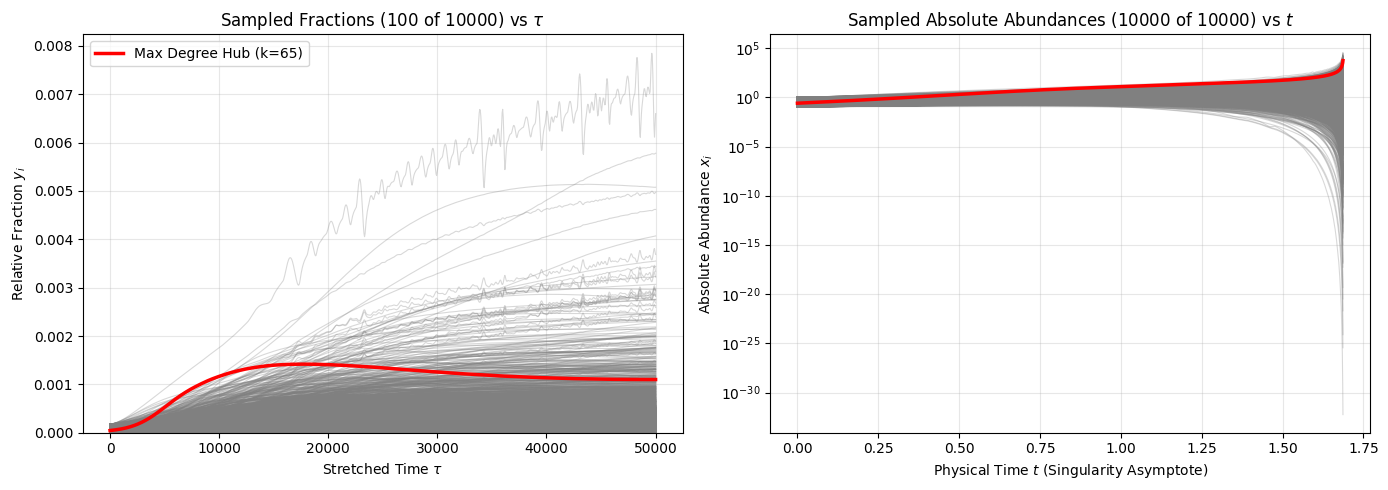

The finite-time singularity occurs exactly at t* ≈ 1.6868


In [19]:
import numpy as np
import networkx as nx
import scipy.sparse as sp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def rescaled_glv_sparse(tau, state, N, W_sparse):
    """
    The ODE system optimized for sparse matrix-vector multiplication.
    """
    y = state[:N]    
    M = state[N]     
    t = state[N+1]   
    
    # Sparse matrix-vector multiplication
    F = W_sparse @ y 
    phi = np.dot(y, F) 
    sq_sum = np.sum(y**2) 
    
    # Differential Equations
    dydtau = y * ((F - phi) - (y - sq_sum))
    dMdtau = 1.0 + M * (phi - sq_sum)
    dtdtau = 1.0 / M
    
    return np.concatenate((dydtau, [dMdtau], [dtdtau]))

# ==========================================
# Simulation Setup: Large Scale
# ==========================================
N = 10_000    # 10k species
C = 8.0      # Average degree

np.random.seed(42)

# 1. Generate Exponential Configuration Model
print(f"Generating sparse Configuration Model (N={N})...")
degree_sequence = np.random.exponential(scale=C, size=N).astype(int)
degree_sequence = np.maximum(degree_sequence, 1) # Prevent isolated nodes
if np.sum(degree_sequence) % 2 != 0:
    degree_sequence[0] += 1

G = nx.configuration_model(degree_sequence)
G = nx.Graph(G) # Remove parallel edges/self-loops

# 2. Convert to SciPy Sparse Matrix for efficiency
A_sparse = nx.to_scipy_sparse_array(G, format='csr')

# Find the Max Degree Hub before adding weights
degrees = np.array(A_sparse.sum(axis=1)).flatten()
max_degree_node = np.argmax(degrees)
print(f"Network built. Highest degree hub is Node {max_degree_node} with k={degrees[max_degree_node]:.0f}")

# ==========================================
# 3. Calculate Critical Mu and Apply Exact Interaction Strengths
# ==========================================
# Calculate the empirical rescaled degrees (g = k / C)
g_array = degrees / C

# Calculate the mean of the squared rescaled degrees: <g^2>
g_squared_mean = np.mean(g_array**2)

# Set mu to the critical value defined in the paper
mu_c = 1.0 / g_squared_mean
mu = mu_c  
print(f"Calculated Critical Interaction Strength (mu_c): {mu_c:.4f}")

sigma = 0.5   # Heterogeneity of the interactions

# z_ij is a standard normal variable N(0, 1)
z = np.random.normal(loc=0.0, scale=1.0, size=A_sparse.data.shape)

# Calculate alpha for every existing edge: alpha_ij = mu/C + (sigma/sqrt(C)) * z_ij
alpha = (mu / C) + (sigma / np.sqrt(C)) * z

# Apply to the sparse adjacency matrix (W_ij = A_ij * alpha_ij)
W_sparse = A_sparse.copy()
W_sparse.data = W_sparse.data * alpha

# ==========================================
# Initialize and Integrate
# ==========================================
x_initial = np.random.uniform(0.1, 1.0, N)  
M_0 = np.sum(x_initial)                     
y_0 = x_initial / M_0                       
t_0 = 0.0                                   

initial_state = np.concatenate((y_0, [M_0], [t_0]))

tau_span = (0, 5*1e4)
tau_eval = np.linspace(tau_span[0], tau_span[1], 1000)

print(f"Integrating N={N} rescaled ODEs (this might take a few seconds)...")
solution = solve_ivp(
    fun=rescaled_glv_sparse,
    t_span=tau_span,
    y0=initial_state,
    t_eval=tau_eval,
    args=(N, W_sparse),
    method='RK45'
)
print("Integration complete!")

# ==========================================
# Trajectory Sampling Logic
# ==========================================
# Select 99 random nodes to plot (excluding the max degree node)
all_nodes = np.arange(N)
remaining_nodes = np.delete(all_nodes, max_degree_node)
sample_size = 9999
sampled_nodes = np.random.choice(remaining_nodes, size=sample_size, replace=False)

# Add our max degree hub to the list of nodes to plot
plot_indices = np.append(sampled_nodes, max_degree_node)

y_trajectories = solution.y[plot_indices, :]
M_trajectory = solution.y[N, :]
t_trajectory = solution.y[N+1, :]
x_trajectories = y_trajectories * M_trajectory

# The max degree hub is the last index in our sampled subset
hub_plot_idx = sample_size

# ==========================================
# Plotting
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: The Safe Simulation (Fractions vs Tau)
for idx, original_node_id in enumerate(plot_indices):
    if idx == hub_plot_idx:
        axes[0].plot(solution.t, y_trajectories[idx, :], lw=2.5, color='red', zorder=10, 
                     label=f'Max Degree Hub (k={degrees[original_node_id]:.0f})')
    else:
        axes[0].plot(solution.t, y_trajectories[idx, :], lw=0.8, color='gray', alpha=0.3)

axes[0].set_title(f"Sampled Fractions (100 of {N}) vs $\\tau$")
axes[0].set_xlabel("Stretched Time $\\tau$")
axes[0].set_ylabel("Relative Fraction $y_i$")
axes[0].set_ylim(bottom=0)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: The Recovered Reality (Absolute Abundance vs Physical Time)
for idx, original_node_id in enumerate(plot_indices):
    if idx == hub_plot_idx:
        axes[1].plot(t_trajectory, x_trajectories[idx, :], lw=2.5, color='red', zorder=10)
    else:
        axes[1].plot(t_trajectory, x_trajectories[idx, :], lw=0.8, color='gray', alpha=0.3)

axes[1].set_title(f"Sampled Absolute Abundances ({sample_size+1} of {N}) vs $t$")
axes[1].set_xlabel("Physical Time $t$ (Singularity Asymptote)")
axes[1].set_ylabel("Absolute Abundance $x_i$")
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"The finite-time singularity occurs exactly at t* ≈ {t_trajectory[-1]:.4f}")

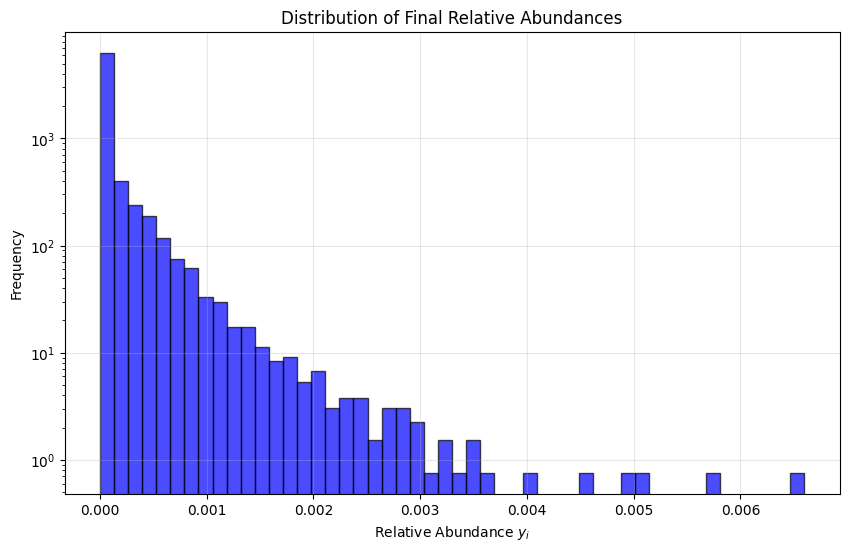

In [20]:
# ==========================================
# Plot Distribution of Final Relative Abundances
# ==========================================
final_y = y_trajectories[:, -1]

plt.figure(figsize=(10, 6))
plt.hist(final_y, bins=50, alpha=0.7, color='blue', edgecolor='black',density=True)
plt.title("Distribution of Final Relative Abundances")
plt.xlabel("Relative Abundance $y_i$")
plt.ylabel("Frequency")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()